In [1]:
pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 9.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
#necessary libray
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import OneHotEncoder as SklearnOHE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline 
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from feature_engine.encoding import CountFrequencyEncoder
import category_encoders as ce
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns',500)

In [3]:
#import the dataset 
data = pd.read_csv('/kaggle/input/datasets/oluwanifemiabimbola/loandata/Loan_Default.csv')
df = data.copy()

In [4]:
#data understanding 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
#checking missing value
data.isna().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [6]:
#dropping the id and age
data = data.drop(['ID','year'],axis=1)

In [7]:
#checking for the duplicated data
data.duplicated().sum()

np.int64(0)

In [8]:
#data sample
data.sample(5)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
96694,cf,Joint,pre,type1,p3,l1,nopc,nob/c,456500,4.990,0.5980,1600.00,360.0,neg_amm,not_int,not_lpsm,588000.0,sb,pr,home,1U,8460.0,CRIF,674,EXP,35-44,not_inst,77.636054,south,direct,0,41.0
22172,cf,Male,nopre,type1,p3,l1,nopc,nob/c,236500,3.375,-0.3035,2500.00,360.0,not_neg,not_int,not_lpsm,508000.0,sb,pr,home,1U,3360.0,CIB,765,CIB,35-44,not_inst,46.555118,North,direct,0,32.0
31264,cf,Female,nopre,type1,p3,l1,nopc,nob/c,486500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,548000.0,sb,pr,home,1U,8640.0,EXP,859,CIB,35-44,to_inst,88.777372,south,direct,1,41.0
148319,cf,Male,nopre,type1,p1,l1,nopc,nob/c,136500,4.990,1.3881,4604.03,360.0,not_neg,not_int,not_lpsm,158000.0,sb,ir,home,1U,4260.0,CRIF,542,CIB,45-54,to_inst,86.392405,North-East,direct,0,38.0
26078,cf,Sex Not Available,nopre,type2,p4,l1,nopc,b/c,86500,2.990,0.4002,3536.52,360.0,not_neg,not_int,not_lpsm,198000.0,sb,pr,home,1U,2820.0,CIB,886,EXP,>74,to_inst,43.686869,south,direct,0,25.0


In [9]:
#data understanding 
data['loan_limit'].value_counts()

loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64

In [10]:
#more data understanding
data.describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [11]:
#loan distribution within the loan limit
data.groupby('loan_limit')['loan_amount'].mean()

loan_limit
cf     317438.395839
ncf    522270.695530
Name: loan_amount, dtype: float64

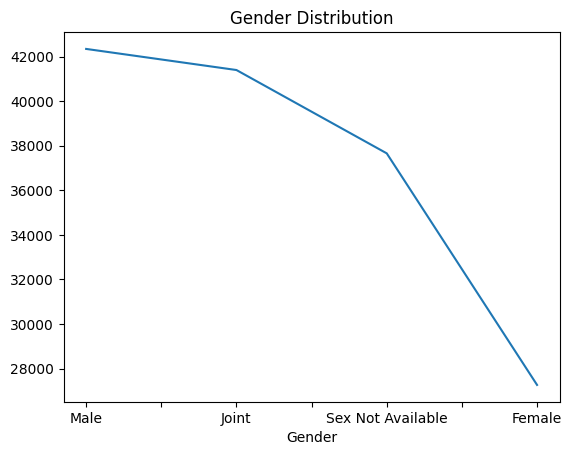

In [12]:
#gender distribution
gender_dist = data['Gender'].value_counts()
gender_dist.plot(kind='line')
plt.title('Gender Distribution')
plt.show()

Text(0.5, 1.0, '% of Approve distribution')

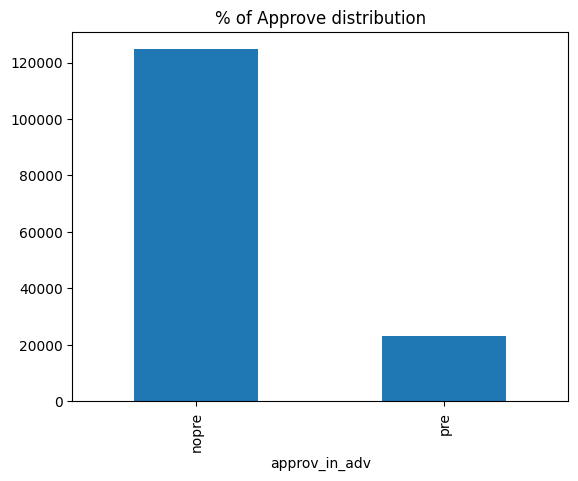

In [13]:
#approvein advance distribution
approve_in = data['approv_in_adv'].value_counts()
approve_in.plot(kind='bar')
plt.title('% of Approve distribution')

In [14]:
#most requested type of loan 
data.groupby('loan_type')['Status'].value_counts()

loan_type  Status
type1      0         87398
           1         25775
type2      0         13590
           1          7172
type3      0         11043
           1          3692
Name: count, dtype: int64

In [15]:
#loan limit and approva rate 
data.groupby('loan_limit')['Status'].value_counts()

loan_limit  Status
cf          0         102904
            1          32444
ncf         0           6664
            1           3314
Name: count, dtype: int64

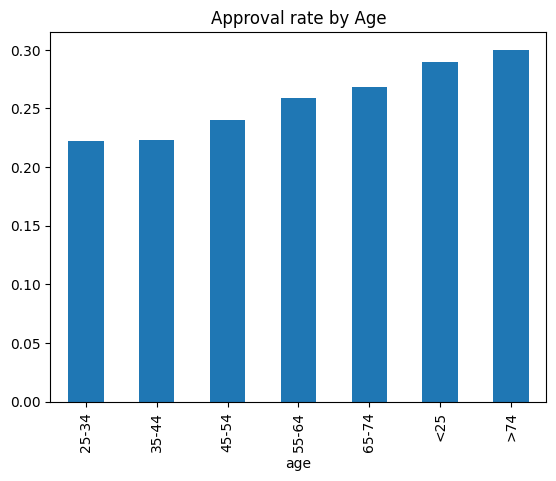

In [16]:
#agegroup and aproval rate
age_group = data.groupby('age')['Status'].mean()
age_group.plot(kind='bar')
plt.title('Approval rate by Age')
plt.show()

In [17]:
#extracting the numerical column
numerical_column = data.select_dtypes(include='number')

In [18]:
numerical_column.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [19]:
#correlation between the numerical data
numerical_column.corr()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
loan_amount,1.000000,-0.150844,-0.377272,0.065556,0.174474,0.734249,0.456065,0.004438,0.038869,-0.036825,0.015029
rate_of_interest,-0.150844,1.000000,0.614908,-0.076473,0.209330,-0.122613,-0.041809,-0.001331,-0.000220,0.022957,0.055124
Interest_rate_spread,-0.377272,0.614908,1.000000,0.033037,-0.157139,-0.334571,-0.151333,-0.001738,0.040257,NaN,0.078178
Upfront_charges,0.065556,-0.076473,0.033037,1.000000,-0.054960,0.053043,0.016580,-0.001484,-0.031347,-0.019138,0.000115
term,0.174474,0.209330,-0.157139,-0.054960,1.000000,0.045117,-0.053785,-0.003149,0.106834,-0.000240,0.110572
property_value,0.734249,-0.122613,-0.334571,0.053043,0.045117,1.000000,0.414883,0.002430,-0.215102,-0.048864,-0.056288
income,0.456065,-0.041809,-0.151333,0.016580,-0.053785,0.414883,1.000000,0.000802,-0.066203,-0.065119,-0.267807
Credit_Score,0.004438,-0.001331,-0.001738,-0.001484,-0.003149,0.002430,0.000802,1.000000,-0.005533,0.004004,-0.000313
LTV,0.038869,-0.000220,0.040257,-0.031347,0.106834,-0.215102,-0.066203,-0.005533,1.000000,0.038895,0.156557
Status,-0.036825,0.022957,NaN,-0.019138,-0.000240,-0.048864,-0.065119,0.004004,0.038895,1.000000,0.078083


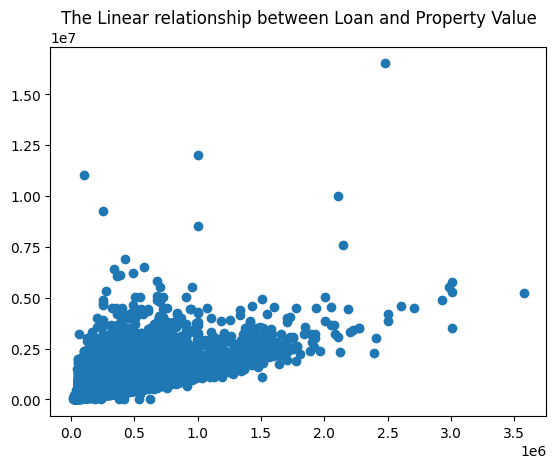

In [20]:
#feature relationship
plt.scatter(data=numerical_column, x='loan_amount', y='property_value')
plt.title('The Linear relationship between Loan and Property Value')
plt.show()

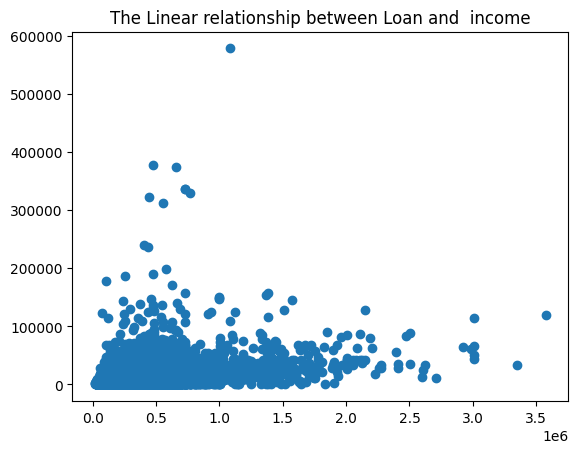

In [21]:
#feature relationship
plt.scatter(data=numerical_column, x='loan_amount', y='income')
plt.title('The Linear relationship between Loan and  income')
plt.show()

In [22]:
numerical_column.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

<Axes: >

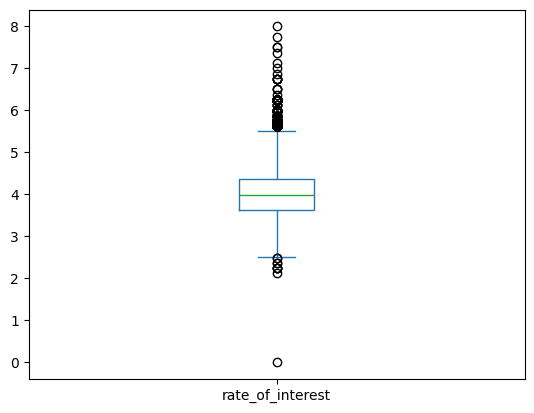

In [23]:
#numerical data distributions
numerical_column['rate_of_interest'].plot(kind='box')

<Axes: ylabel='Frequency'>

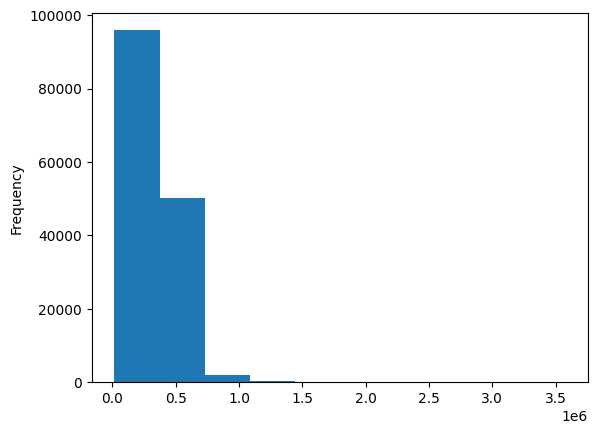

In [24]:
#numerical data distribution
numerical_column['loan_amount'].plot(kind='hist')

<Axes: >

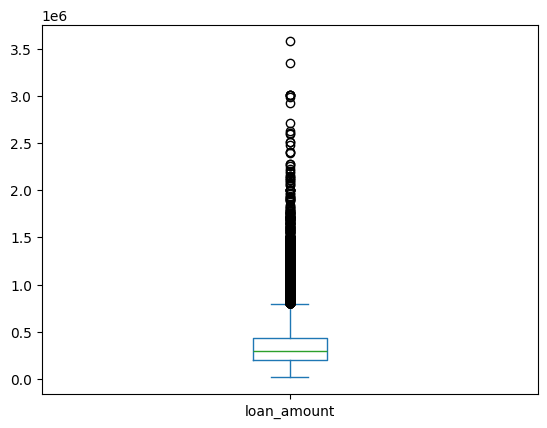

In [25]:
#numerical data distribution
numerical_column['loan_amount'].plot(kind='box')

In [26]:
num = data.select_dtypes(include='number')

In [27]:
#chekcing the skew
num.skew()

loan_amount               1.666998
rate_of_interest          0.388406
Interest_rate_spread      0.280762
Upfront_charges           1.754076
term                     -2.174822
property_value            4.586276
income                   17.307695
Credit_Score              0.004767
LTV                     120.615337
Status                    1.176762
dtir1                    -0.551465
dtype: float64

Splitting of Data and Feature Engineering 


In [28]:
#splitting the data set
X = data.drop('Status',axis=1)
y = data['Status']

In [29]:
#splitting into test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [30]:
#filling th emissing value with mean using pipeline
filling_na_mean =Pipeline(steps=[
        ("meanformissing",SimpleImputer(missing_values=np.nan, strategy='mean'))])

In [31]:
#extracting the features for mean
mean_numeric =['rate_of_interest', 'Interest_rate_spread','Upfront_charges','term',
                    'property_value','income','LTV','dtir1']

In [32]:
# # filling the missing value with the mean of each column
# def filling_the_na(column):
#     return column.fillna(column.mean())

# data_for_mean_na = ['rate_of_interest',
#                     'Interest_rate_spread',
#                     'Upfront_charges',
#                     'term',
#                     'property_value',
#                     'income',
#                     'LTV',
#                     'dtir1']

# data[data_for_mean_na] = data[data_for_mean_na].apply(filling_the_na)

In [33]:
#filling the missing value with most frequency data in a pipeline
filling_most_na=Pipeline(steps=[("missingmodevalue",SimpleImputer(missing_values=np.nan, strategy="most_frequent"))])

In [34]:
#data for the most frequent
most_frequent = ['Neg_ammortization', 'submission_of_application',
                     'age', 'loan_limit', 'approv_in_adv', 'loan_purpose']

In [35]:
# # missing value sorting
# # filling features missing values with the common label
# def filling_the_nas(column):
#     return column.fillna(column.mode()[0])

# data_for_mean_nas = ['Neg_ammortization',
#                      'submission_of_application',
#                      'age',
#                      'loan_limit',
#                      'approv_in_adv',
#                      'loan_purpose']

# data[data_for_mean_nas] = data[data_for_mean_nas].apply(filling_the_nas)

creating a custome transformer for outlier

In [36]:
%%writefile custom_transformers.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

def winsorize(X, lower=0.05, upper=0.95):
    Q1 = np.percentile(X, lower * 100, axis=0)
    Q3 = np.percentile(X, upper * 100, axis=0)
    return np.clip(X, Q1, Q3)

class NamedWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.05, upper=0.95):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_ = list(X.columns)
        else:
            self.feature_names_ = [f"x{i}" for i in range(X.shape[1])]
        
        X_arr = X.values if hasattr(X, 'values') else X
        self.lower_bounds_ = np.percentile(X_arr, self.lower * 100, axis=0)
        self.upper_bounds_ = np.percentile(X_arr, self.upper * 100, axis=0)
        return self

    def transform(self, X):
        X_arr = X.values if hasattr(X, 'values') else X
        clipped = np.clip(X_arr, self.lower_bounds_, self.upper_bounds_)
        return pd.DataFrame(clipped, columns=self.feature_names_,
                            index=X.index if hasattr(X, 'index') else None)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)

Writing custom_transformers.py


In [37]:
#confirm the custom transformer
import os
os.listdir()

['.virtual_documents', 'custom_transformers.py']

In [38]:
# #encoding the categorical data for the onehot encoder
# one_hot_encoder = OneHotEncoder(
#     variables=['Gender','loan_type',
#               'loan_purpose','occupancy_type',
#               'total_units','credit_type','age','Region'],
#     drop_last=True)

# one_hot_encoder.fit(X_train)
# X_train = one_hot_encoder.transform(X_train)
# X_test = one_hot_encoder.transform(X_test)

# print(X_train.head())

In [39]:
# #encoding the categorical data for the binary encoder
# binary_encoder = ce.BinaryEncoder(cols=['loan_limit','approv_in_adv',
#                                         'Credit_Worthiness','open_credit',
#                                         'business_or_commercial',
#                                          'Neg_ammortization',
#                                          'interest_only',
#                                          'lump_sum_payment',
#                                          'construction_type',
#                                          'Secured_by','Security_Type',
#                                          'co-applicant_credit_type',
#                                         'submission_of_application'],
#                                   return_df=True,)
# #fit the transform on the training and test data
# binary_encoder.fit(X_train)
# X_train = binary_encoder.transform(X_train)
# X_test = binary_encoder.transform(X_test)

# print(X_train.head())

In [40]:
#extracting the numerical data
numerical_smote = data.select_dtypes(include='number')

In [41]:
numerical_smote.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [42]:
#defining the pipeline for the imbalance data
imbalance_data = Pipeline(steps=[
    ("Smoteimbalance",SMOTE(sampling_strategy='minority',random_state=42))])

In [43]:
# #using smote to sort Imbalance dataset
# smote = SMOTE(sampling_strategy='minority', random_state=42)
# X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
#         color=['skyblue','salmon'])
# plt.xticks([0,1], ['Not Default', 'Loan Default'])
# plt.ylabel("Count")
# plt.title("Class Distribution AFTER SMOTE")
# plt.show()

In [44]:
#ordinal encoder
ordinal = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=int(-1))

In [45]:
#so many outlier , sorting with IQR
numerical_column = ['loan_amount', 'Credit_Score']
most_frequent = ['Neg_ammortization', 'submission_of_application',
                     'age', 'loan_limit', 'approv_in_adv', 'loan_purpose']
mean_numeric =['rate_of_interest', 'Interest_rate_spread','Upfront_charges','term',
                    'property_value','income','LTV','dtir1']
one_hot_encoder_numeric =['Gender','loan_type','occupancy_type',
                          'total_units','credit_type','Region']
ordinal_numeric =['Credit_Worthiness','open_credit',
                 'business_or_commercial',
                 'interest_only', 'lump_sum_payment', 'construction_type',
                 'Secured_by','Security_Type','co-applicant_credit_type']

In [46]:
#the custom outlier capping 
from custom_transformers import winsorize, NamedWinsorizer

winsorization_pipeline = Pipeline(steps=[
    ("winsorization", NamedWinsorizer(lower=0.05, upper=0.95))
])

In [47]:
#onehot encoder
one_hot_encoder = Pipeline(steps=[
    ('onehot', SklearnOHE(handle_unknown='ignore',sparse_output=False))
])

In [49]:
#numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('winsorizer', NamedWinsorizer(lower=0.05, upper=0.95))
])


In [50]:
#for the missing data not to over lap,fill the data and convert the categorical data
filling_most_na = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocess = ColumnTransformer([
    ("mode_binary",       filling_most_na,      most_frequent),
    ("missingvalue_mean", filling_na_mean,       mean_numeric),
    ("numerical",         numerical_pipeline,    numerical_column),
    ("onehotencoder",     one_hot_encoder,       one_hot_encoder_numeric),
    ("binaryencoder",     OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1),ordinal_numeric),
], remainder='drop')

In [51]:
preprocess

ColumnTransformer(transformers=[('mode_binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Neg_ammortization',
                                  'submission_of_application', 'age',
                                  'loan_limit', 'approv_in_adv',
                                  'loan_purpose']),
                                ('missingvalue_mean',
                                 Pipeline(steps=[('meanformissin...
                                                                sparse_output=False))]),
                                 ['Gender', 'loan_type', 'occupancy_type',
                                  'total_units', 'credit_type', 'Region']),
                                ('binaryencoder',
                                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['Credit_Worthiness', 'open_credit',
                                  'business_or_commercial', 'interest_only',
                                  'lump_sum_payment', 'construction_type',
                                  'Secured_by', 'Security_Type',
                                  'co-applicant_credit_type'])])

In [52]:
#connecting the preprocess and estimatror
pipe = ImbPipeline(steps=[
    ('columntransformer', preprocess),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(max_iter=1000, solver='saga'))
])

In [53]:
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('mode_binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Neg_ammortization',
                                                   'submission_of_application',
                                                   'age', 'loan_limit',
                                                   'approv_in_adv',
                                                   'loan_purpose']),
                                                 ('missingvalue_...
                                                                 unknown_value=-1),
                                                  ['Credit_Worthiness',
                                                   'open_credit',
                                                   'business_or_commercial',
                                                   'interest_only',
                                                   'lump_sum_payment',
                                                   'construction_type',
                                                   'Secured_by',
                                                   'Security_Type',
                                                   'co-applicant_credit_type'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
                ('scaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, solver='saga'))])

In [54]:
#hyperparameter tuning 
#logistic regression paramter to tune 
grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['saga']  
}

In [ ]:
#fitting the grid with randomsearch
X_sample, y_sample = resample(X_train, y_train, n_samples=10000, random_state=42)
rs = RandomizedSearchCV(pipe, param_distributions=grid, n_iter=20, cv=5,
                        scoring='roc_auc', random_state=42)
rs.fit(X_sample, y_sample)
pipe = rs.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.

In [ ]:
print("Best params:", rs.best_params_)
print("Best score:", rs.best_score_)

In [ ]:
pipe

In [ ]:
y_pred_sm = pipe.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print('ROC-AUC:',roc_auc_score(y_test,y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

In [ ]:
# Compare train vs test performance for overfitting 
y_train_pred = pipe.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_sm))

In [ ]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X_train, y_train, cv=5)
scores
print(scores)
print(scores.mean())

In [ ]:
# #improving the model precision by using shap to understand the feature ,
# #using shap
# Convert numpy array to DataFrame first
# Get column names from original X_train (before SMOTE)
feature_names = X_train.columns.tolist()

# Convert both to DataFrame using original column names
X_train_sm_df = pd.DataFrame(X_train, columns=feature_names)
X_test_sm_df = pd.DataFrame(X_test, columns=feature_names)

# Now sample works
X_test_sample = X_test_sm_df.sample(500, random_state=42)


explainer = shap.LinearExplainer(pipe, X_train)

# Calculate SHAP values on the sample
shap_values = explainer(X_test_sample)

In [ ]:
# Get mean absolute SHAP values
vals = np.abs(shap_values.values).mean(axis=0)  

feature_names = X_test_sm_df.columns.tolist()  

# Create dataframe and sort
shap_df = pd.DataFrame({
    'feature': feature_names,
    'importance': vals
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(14, 10))
plt.barh(shap_df['feature'], shap_df['importance'])
plt.title('SHAP Feature Importance CatBoost')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.show()

In [ ]:
import  joblib

joblib.dump(model, 'logisticloan.pkl')